POST TEST PRAKTIKUM ALGORITMA DAN PEMROGRAMAN 2026
KELAS B - KELOMPOK 6

In [3]:
pip install pandas matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 3.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.8 MB 2.7 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.8 MB 3.1 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.8 MB 2.6 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.8 MB 2.5 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.8 MB 2.8 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.8 MB 2.7 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.8 MB 2.8 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.8 MB 2.6 MB/s eta 0:00:02
   ----------------------- -----


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# Import library wajib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Pengaturan tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

Matplotlib is building the font cache; this may take a moment.


In [18]:
# Membaca dataset Kelas B
# Catatan responsi: dataset kelas B dipisahkan oleh titik koma, sehingga wajib memakai sep=';'
df = pd.read_csv("Kelas B_CO2 Emissions by Car.csv", sep=";")

# Menampilkan ringkasan awal data
print("Ukuran dataset:", df.shape)
display(df.head())
print("\nInfo kolom:")
df.info()

Ukuran dataset: (679, 10)


,MODEL_YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE_SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL_CONSUMPTION*,CO2_EMISSIONS
0,2001,ACURA,1.7EL,COMPACT,1.7,4,A4,X,9.3,191
1,2001,ACURA,1.7EL,COMPACT,1.7,4,M5,X,8.9,191
2,2001,ACURA,3.2CL,COMPACT,3.2,6,AS5,Z,13.7,265
3,2001,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.8,267
4,2001,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301



Info kolom:
<class 'pandas.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MODEL_YEAR         679 non-null    int64  
 1   MAKE               679 non-null    str    
 2   MODEL              679 non-null    str    
 3   VEHICLE CLASS      679 non-null    str    
 4   ENGINE_SIZE        679 non-null    float64
 5   CYLINDERS          679 non-null    int64  
 6   TRANSMISSION       679 non-null    str    
 7   FUEL               679 non-null    str    
 8   FUEL_CONSUMPTION*  679 non-null    float64
 9   CO2_EMISSIONS      679 non-null    int64  
dtypes: float64(2), int64(3), str(5)
memory usage: 53.2 KB


In [19]:
# Validasi kolom yang dibutuhkan
required_columns = [
    "MAKE", "MODEL", "VEHICLE CLASS", "ENGINE_SIZE", "CYLINDERS",
    "TRANSMISSION", "FUEL", "FUEL_CONSUMPTION*", "CO2_EMISSIONS"
]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Kolom berikut tidak ditemukan pada dataset: {missing_columns}")

# Nama kolom yang sering dipakai
fuel_consumption_col = "FUEL_CONSUMPTION*"
co2_col = "CO2_EMISSIONS"
engine_col = "ENGINE_SIZE"

# Membuat kolom tambahan untuk soal Kategori C
df["Emission_Ratio"] = df[co2_col] / df[fuel_consumption_col]

# Membuat kolom binning untuk soal Kategori D
df["ENGINE_BIN"] = pd.cut(
    df[engine_col],
    bins=3,
    labels=["Small", "Medium", "Large"],
    include_lowest=True
)

display(df[["MAKE", "MODEL", engine_col, fuel_consumption_col, co2_col, "Emission_Ratio", "ENGINE_BIN"]].head())

,MAKE,MODEL,ENGINE_SIZE,FUEL_CONSUMPTION*,CO2_EMISSIONS,Emission_Ratio,ENGINE_BIN
0,ACURA,1.7EL,1.7,9.3,191,20.537634,Small
1,ACURA,1.7EL,1.7,8.9,191,21.460674,Small
2,ACURA,3.2CL,3.2,13.7,265,19.343066,Small
3,ACURA,3.2TL,3.2,13.8,267,19.347826,Small
4,ACURA,3.5RL,3.5,15.0,301,20.066667,Medium


GRAFIK 1 - AGREGASI
nilai rata-rata FUEL_CONSUMPTION berdasarkan kombinasi kelompok MAKE dan jenis FUEL.

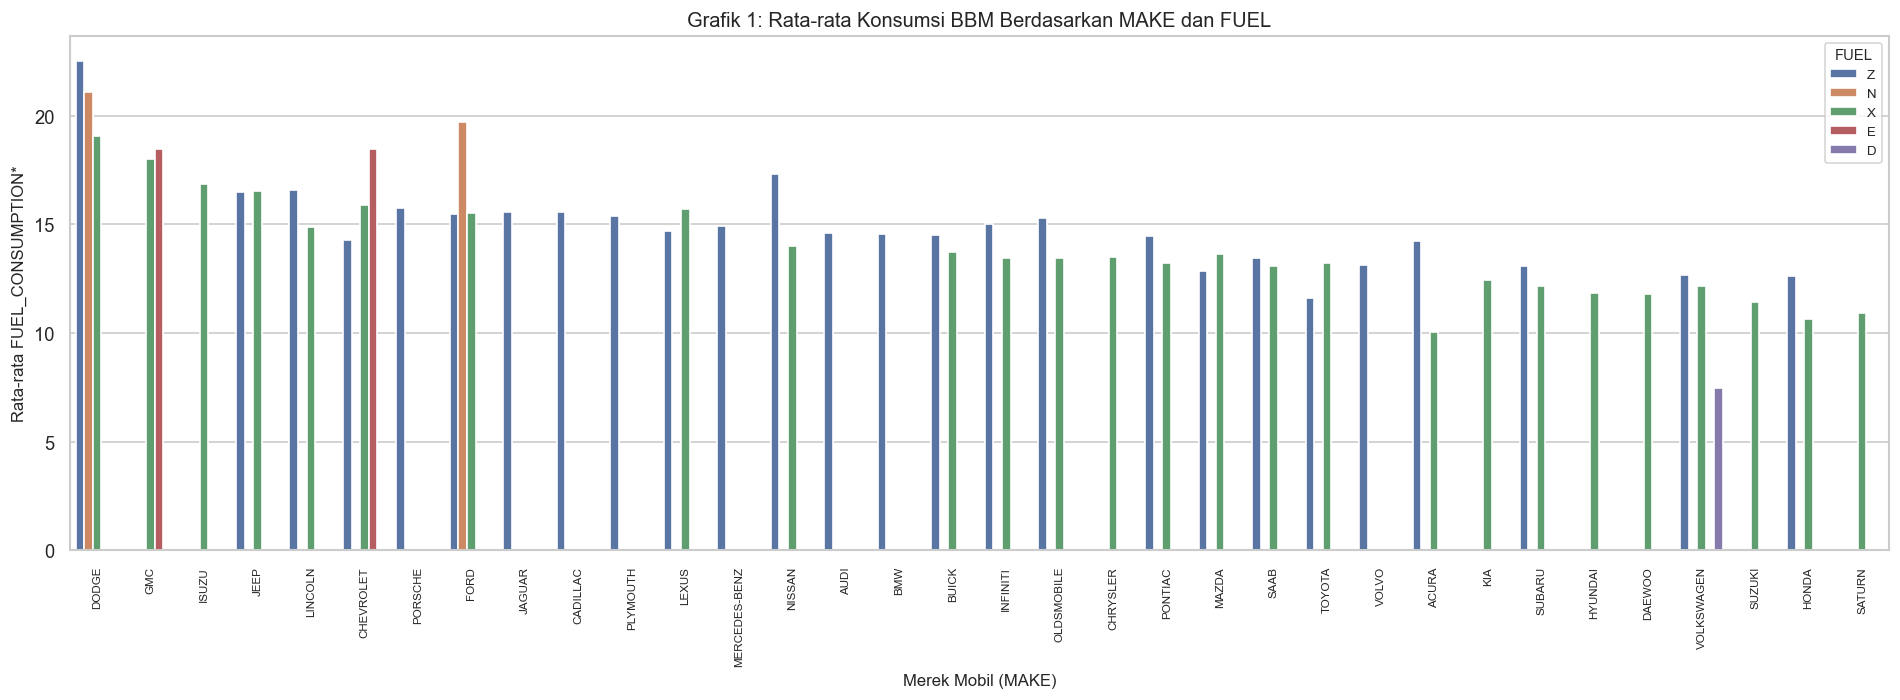

In [20]:
def plot_grafik_1(ax=None):
    """Grafik 1: Grouped Bar Chart rata-rata FUEL_CONSUMPTION* berdasarkan MAKE dan FUEL."""
    if ax is None:
        _, ax = plt.subplots(figsize=(16, 6))

    # Agregasi rata-rata konsumsi bahan bakar berdasarkan kombinasi MAKE dan FUEL
    fuel_make_mean = (
        df.groupby(["MAKE", "FUEL"], as_index=False)[fuel_consumption_col]
          .mean()
          .sort_values(fuel_consumption_col, ascending=False)
    )

    # Urutan merek berdasarkan rata-rata konsumsi bahan bakar keseluruhan
    make_order = (
        df.groupby("MAKE")[fuel_consumption_col]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    sns.barplot(
        data=fuel_make_mean,
        x="MAKE",
        y=fuel_consumption_col,
        hue="FUEL",
        order=make_order,
        errorbar=None,
        ax=ax
    )

    ax.set_title("Grafik 1: Rata-rata Konsumsi BBM Berdasarkan MAKE dan FUEL")
    ax.set_xlabel("Merek Mobil (MAKE)")
    ax.set_ylabel("Rata-rata FUEL_CONSUMPTION*")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.legend(title="FUEL", fontsize=8, title_fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(16, 6))
plot_grafik_1(ax=ax)
plt.tight_layout()
plt.show()

GRAFIK 2 - FILTER
Data kendaraan bersilinder genap (4, 6, 8) yang nilai emisinya melebihi nilai rata-rata keseluruhan dataset ditambah 1 standar deviasi.

In [21]:
# Nilai batas filter: rata-rata CO2 seluruh dataset + 1 standar deviasi
co2_threshold = df[co2_col].mean() + df[co2_col].std()

filtered_even_cylinders = df[
    (df["CYLINDERS"].isin([4, 6, 8])) &
    (df[co2_col] > co2_threshold)
].copy()

filtered_even_cylinders["KENDARAAN"] = (
    filtered_even_cylinders["MAKE"] + " - " +
    filtered_even_cylinders["MODEL"] + " (" +
    filtered_even_cylinders["TRANSMISSION"] + ", " +
    filtered_even_cylinders["CYLINDERS"].astype(str) + " cyl)"
)

print(f"Batas emisi CO2 = mean + 1 std = {co2_threshold:.2f}")
print("Jumlah kendaraan hasil filter:", len(filtered_even_cylinders))
display(filtered_even_cylinders[["MAKE", "MODEL", "CYLINDERS", "TRANSMISSION", co2_col]].sort_values(co2_col, ascending=False).head(20))

Batas emisi CO2 = mean + 1 std = 354.03
Jumlah kendaraan hasil filter: 124


,MAKE,MODEL,CYLINDERS,TRANSMISSION,CO2_EMISSIONS
316,GMC,K1500 SIERRA 4X4,8,A4,478
319,GMC,K1500 YUKON 4X4,8,A4,453
321,GMC,K1500 YUKON XL 4X4,8,A4,453
411,LINCOLN,NAVIGATOR 4X4,8,A4,449
214,DODGE,RAM 1500 4X4,8,M5,439
213,DODGE,RAM 1500 4X4,8,A4,435
225,DODGE,RAM 2500 WAGON,8,A4,435
195,DODGE,DAKOTA 4X4,8,A4,432
241,FORD,E250 VAN,8,A4,430
198,DODGE,DURANGO 5.9 R/T 4X4 #,8,A4,428


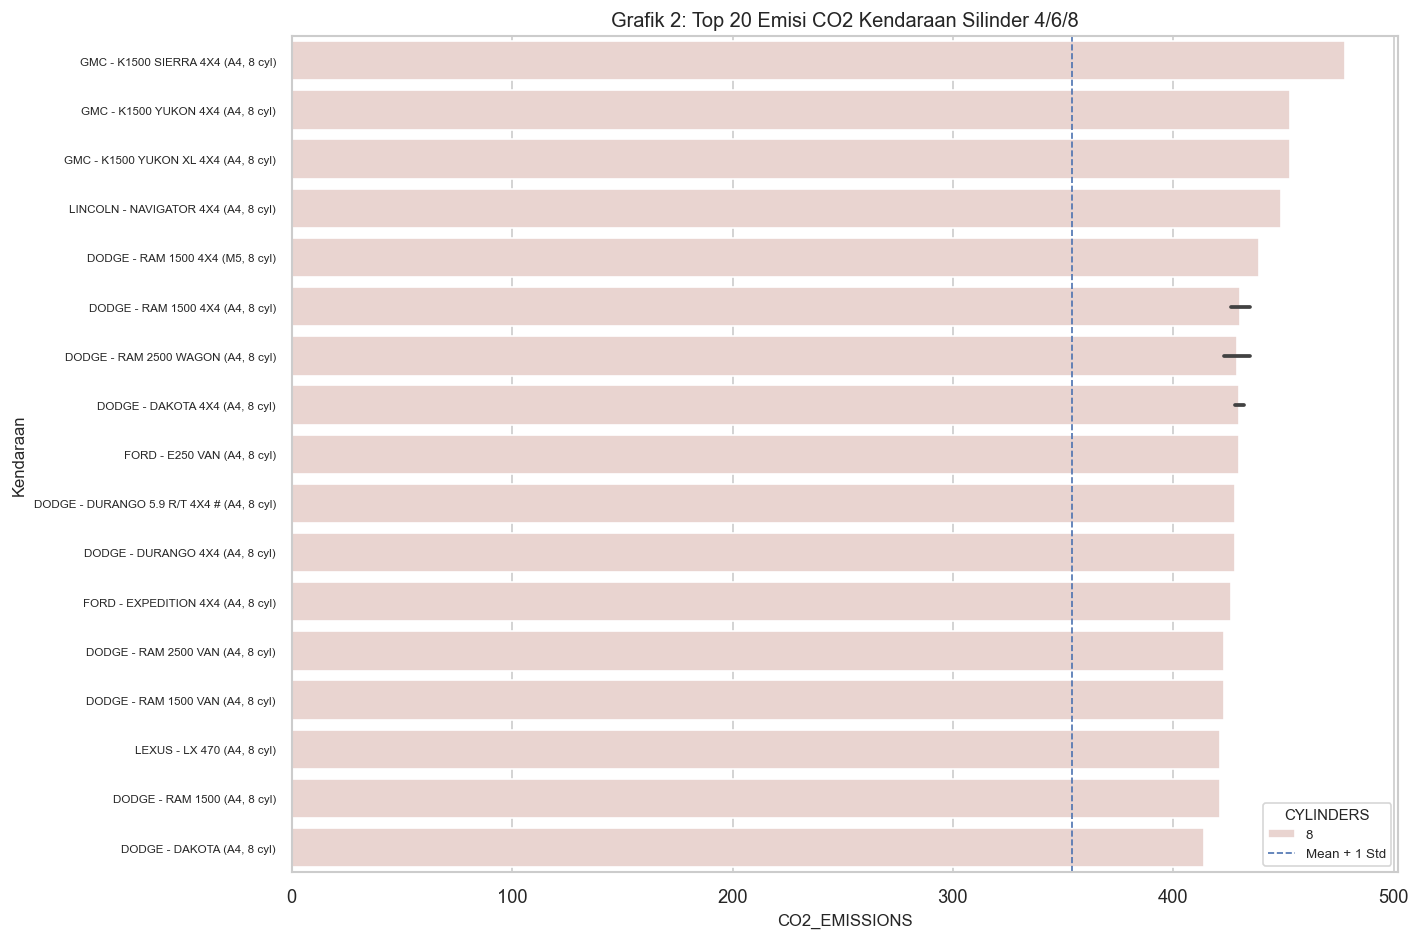

In [22]:
def plot_grafik_2(ax=None, top_n=20):
    """Grafik 2: Bar Chart kendaraan bersilinder 4/6/8 dengan CO2 di atas mean + 1 std."""
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 8))

    plot_data = (
        filtered_even_cylinders
        .sort_values(co2_col, ascending=False)
        .head(top_n)
    )

    sns.barplot(
        data=plot_data,
        y="KENDARAAN",
        x=co2_col,
        hue="CYLINDERS",
        dodge=False,
        ax=ax
    )

    ax.axvline(co2_threshold, linestyle="--", linewidth=1, label="Mean + 1 Std")
    ax.set_title(f"Grafik 2: Top {top_n} Emisi CO2 Kendaraan Silinder 4/6/8")
    ax.set_xlabel("CO2_EMISSIONS")
    ax.set_ylabel("Kendaraan")
    ax.tick_params(axis="y", labelsize=7)
    ax.legend(title="CYLINDERS", fontsize=8, title_fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(12, 8))
plot_grafik_2(ax=ax, top_n=20)
plt.tight_layout()
plt.show()

GRAFIK 3 - KORELASI
Buat kolom baru Emission_Ratio (CO2_EMISSIONS dibagi FUEL_CONSUMPTION*). Analisis hubungannya dengan ukuran kapasitas mesin (ENGINE_SIZE) menggunakan Scatter Plot

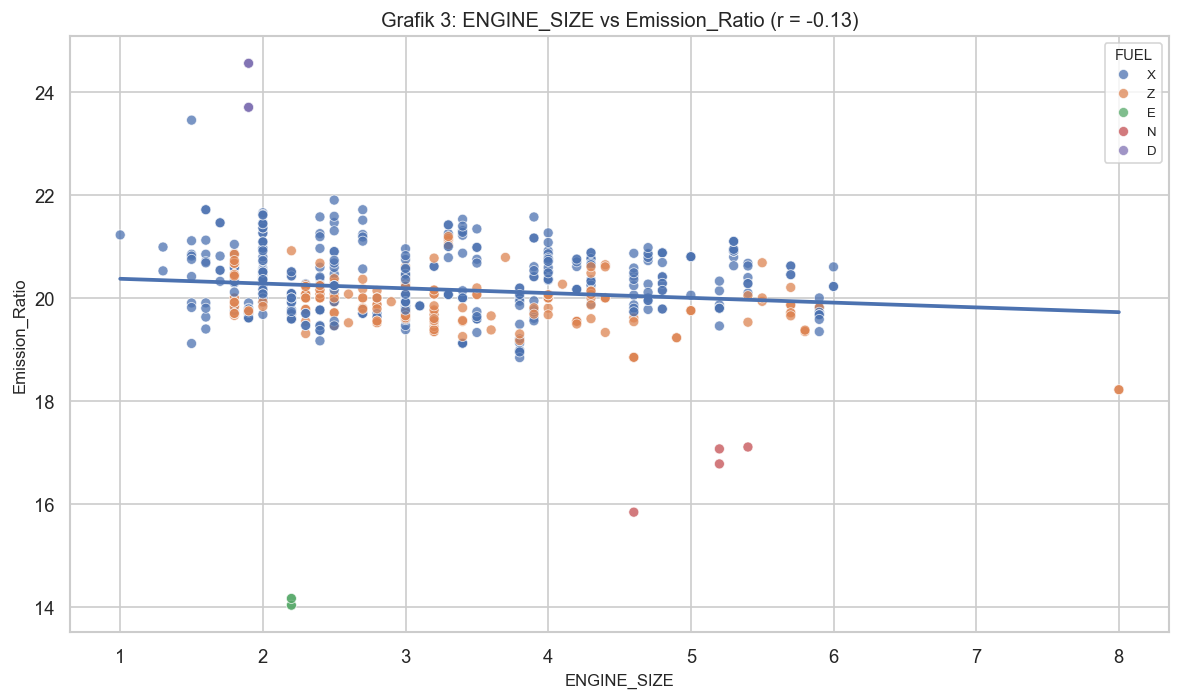

In [23]:
def plot_grafik_3(ax=None):
    """Grafik 3: Scatter Plot hubungan ENGINE_SIZE dengan Emission_Ratio."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=engine_col,
        y="Emission_Ratio",
        hue="FUEL",
        alpha=0.75,
        ax=ax
    )

    # Garis tren umum untuk membantu membaca arah hubungan
    sns.regplot(
        data=df,
        x=engine_col,
        y="Emission_Ratio",
        scatter=False,
        ci=None,
        ax=ax
    )

    corr_value = df[[engine_col, "Emission_Ratio"]].corr().iloc[0, 1]
    ax.set_title(f"Grafik 3: ENGINE_SIZE vs Emission_Ratio (r = {corr_value:.2f})")
    ax.set_xlabel("ENGINE_SIZE")
    ax.set_ylabel("Emission_Ratio")
    ax.legend(title="FUEL", fontsize=8, title_fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(10, 6))
plot_grafik_3(ax=ax)
plt.tight_layout()
plt.show()

GRAFIK 4 - DISTRIBUSI
Binning kapasitas mesin (ENGINE_SIZE) menjadi 3 kelompok ('Small', 'Medium', 'Large').

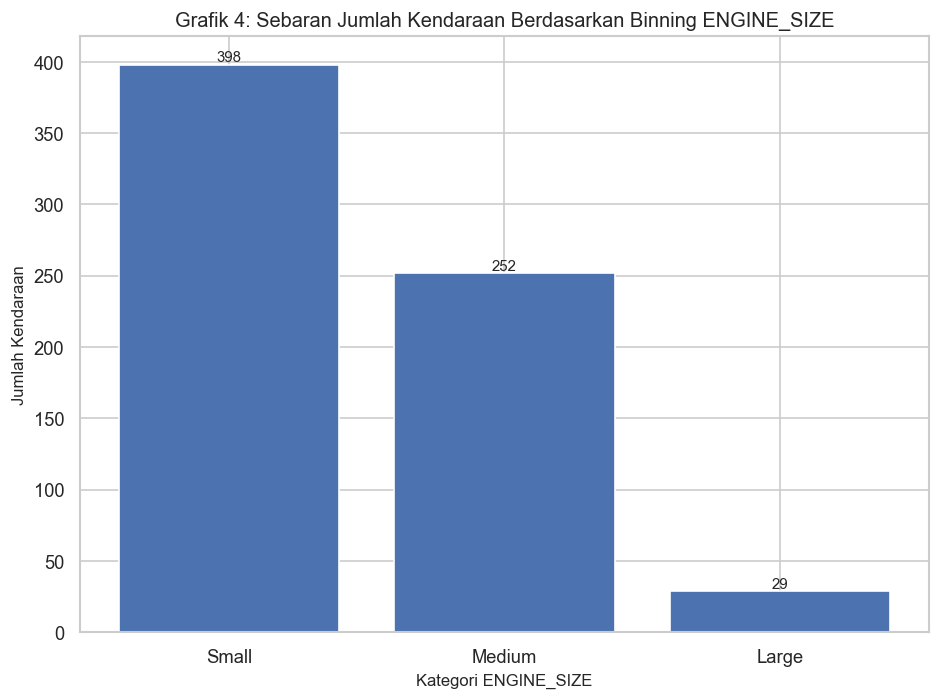

In [24]:
def plot_grafik_4(ax=None):
    """Grafik 4: Bar Chart sebaran jumlah kendaraan berdasarkan ENGINE_BIN."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    bin_order = ["Small", "Medium", "Large"]
    bin_counts = (
        df["ENGINE_BIN"]
        .value_counts()
        .reindex(bin_order)
        .reset_index()
    )
    bin_counts.columns = ["ENGINE_BIN", "Jumlah"]

    ax.bar(
        bin_counts["ENGINE_BIN"].astype(str),
        bin_counts["Jumlah"]
    )

    ax.set_title("Grafik 4: Sebaran Jumlah Kendaraan Berdasarkan Binning ENGINE_SIZE")
    ax.set_xlabel("Kategori ENGINE_SIZE")
    ax.set_ylabel("Jumlah Kendaraan")

    # Menambahkan label angka di atas bar
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", fontsize=9)

    return ax

fig, ax = plt.subplots(figsize=(8, 6))
plot_grafik_4(ax=ax)
plt.tight_layout()
plt.show()

GRAFIK 5 - GABUNGAN 2 X 2

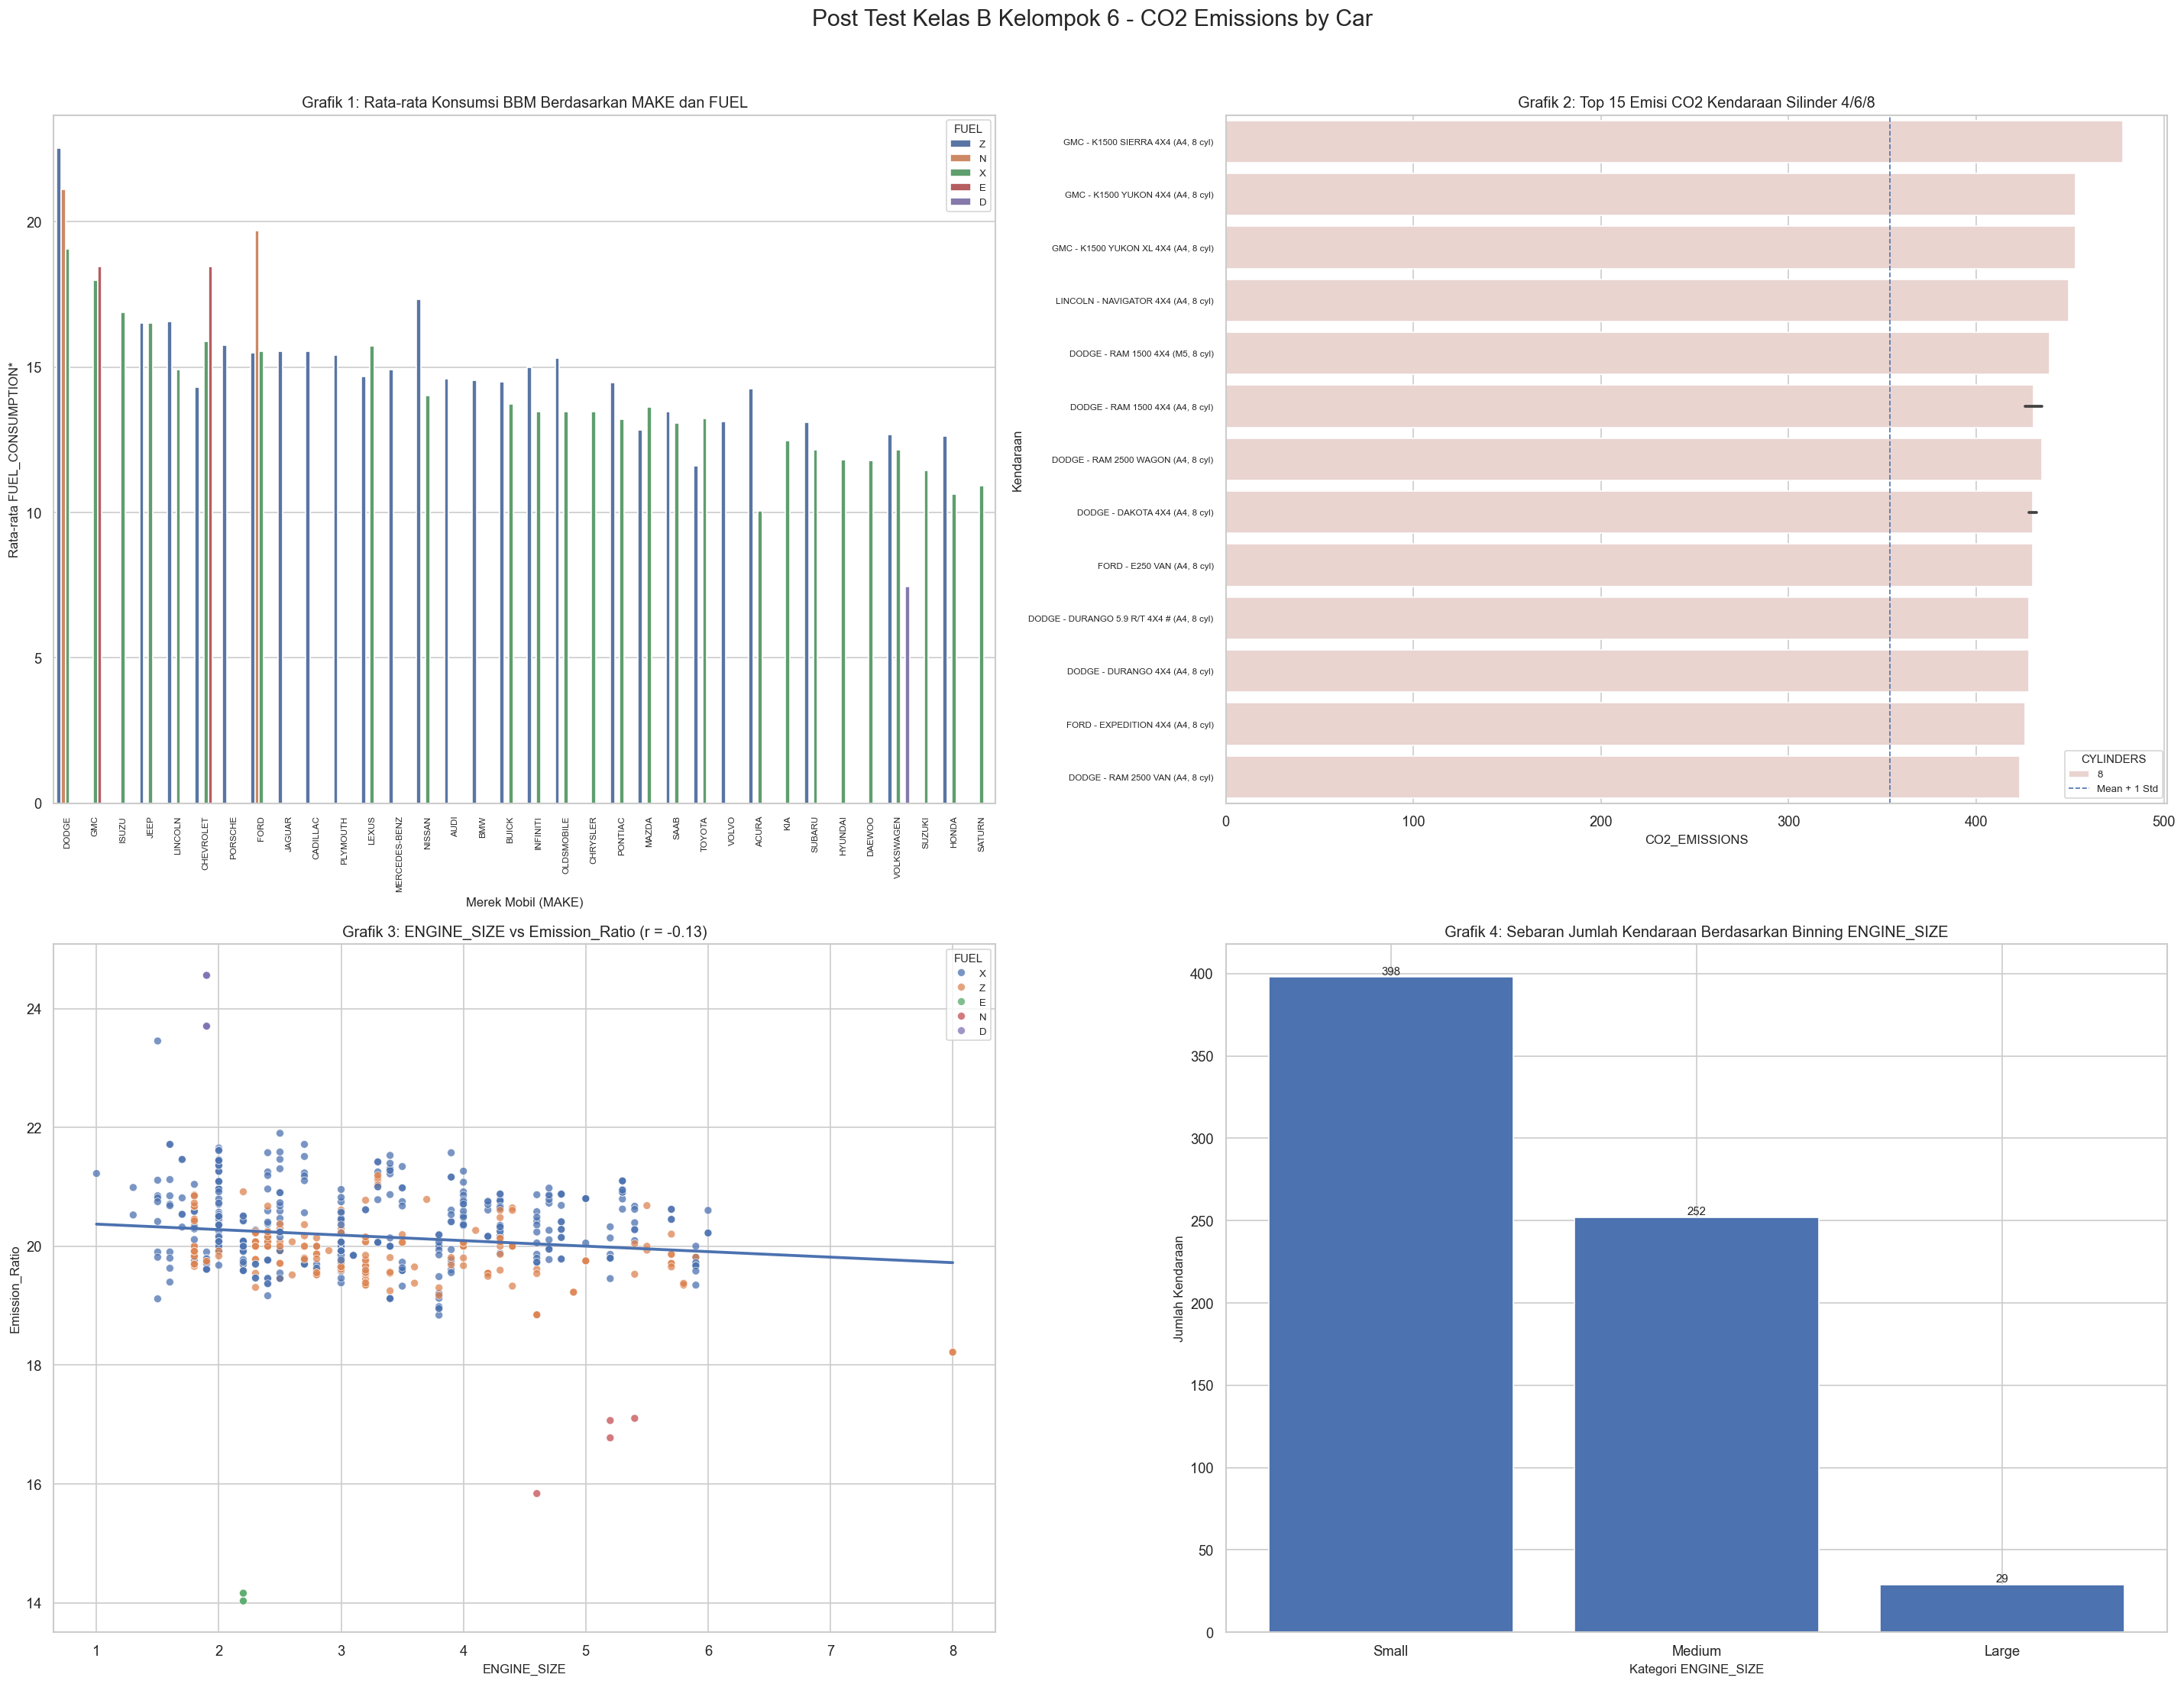

In [25]:
# Grafik 5: Gabungan seluruh visualisasi
fig, axes = plt.subplots(2, 2, figsize=(24, 18))

plot_grafik_1(ax=axes[0, 0])
plot_grafik_2(ax=axes[0, 1], top_n=15)
plot_grafik_3(ax=axes[1, 0])
plot_grafik_4(ax=axes[1, 1])

fig.suptitle("Post Test Kelas B Kelompok 6 - CO2 Emissions by Car", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

RINGKASAN SINGKAT

In [26]:
# Insight otomatis dari hasil pengolahan data
fuel_make_mean = df.groupby(["MAKE", "FUEL"], as_index=False)[fuel_consumption_col].mean()
highest_avg_consumption = fuel_make_mean.sort_values(fuel_consumption_col, ascending=False).iloc[0]

engine_bin_counts = df["ENGINE_BIN"].value_counts().reindex(["Small", "Medium", "Large"])
corr_engine_ratio = df[[engine_col, "Emission_Ratio"]].corr().iloc[0, 1]

print("Insight Grafik 1:")
print(f"Kombinasi MAKE-FUEL dengan rata-rata konsumsi tertinggi: {highest_avg_consumption['MAKE']} - {highest_avg_consumption['FUEL']} ({highest_avg_consumption[fuel_consumption_col]:.2f}).")

print("\nInsight Grafik 2:")
print(f"Terdapat {len(filtered_even_cylinders)} kendaraan bersilinder 4/6/8 dengan CO2_EMISSIONS di atas {co2_threshold:.2f}.")
print("Merek terbanyak pada hasil filter:")
print(filtered_even_cylinders["MAKE"].value_counts().head())

print("\nInsight Grafik 3:")
print(f"Korelasi ENGINE_SIZE dengan Emission_Ratio = {corr_engine_ratio:.3f}.")

print("\nInsight Grafik 4:")
print(engine_bin_counts)

Insight Grafik 1:
Kombinasi MAKE-FUEL dengan rata-rata konsumsi tertinggi: DODGE - Z (22.53).

Insight Grafik 2:
Terdapat 124 kendaraan bersilinder 4/6/8 dengan CO2_EMISSIONS di atas 354.03.
Merek terbanyak pada hasil filter:
MAKE
DODGE        32
GMC          25
CHEVROLET    22
FORD         21
NISSAN        7
Name: count, dtype: int64

Insight Grafik 3:
Korelasi ENGINE_SIZE dengan Emission_Ratio = -0.127.

Insight Grafik 4:
ENGINE_BIN
Small     398
Medium    252
Large      29
Name: count, dtype: int64
